In [1]:
# 1. Install the latest Kaggle CLI client
!pip install --upgrade -q kaggle

# 2. Create the hidden .kaggle directory and save your specific access token
!mkdir -p ~/.kaggle
!echo "KGAT_e28b733576ab116600ea7d7523136ebb" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. Download UrbanSound8K directly to the cloud instance
!kaggle datasets download -d chrisfilo/urbansound8k

# 4. Unzip the downloaded file
import zipfile
import os

print("Unzipping files... this takes about 30 seconds.")
with zipfile.ZipFile("urbansound8k.zip", 'r') as zip_ref:
    zip_ref.extractall("./urbansound8k")
print("Done! Let's check the contents:")
print(os.listdir("./urbansound8k"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 6.1 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.61G/5.61G [02:29<00:00, 40.3MB/s]

Unzipping files... this takes about 30 seconds.
Done! Let's check the contents:
['fold10', 'fold6', 'fold7', 'fold1', 'fold2', 'fold4', 'fold9', 'fold3', 'UrbanSound8K.csv', 'fold5', 'fold8']


Metadata Sample:
      slice_file_name  fold             class
0    100032-3-0-0.wav     5          dog_bark
1  100263-2-0-117.wav     5  children_playing
2  100263-2-0-121.wav     5  children_playing
3  100263-2-0-126.wav     5  children_playing
4  100263-2-0-137.wav     5  children_playing

Loading sample file: ./urbansound8k/fold5/100032-3-0-0.wav (Class: dog_bark)


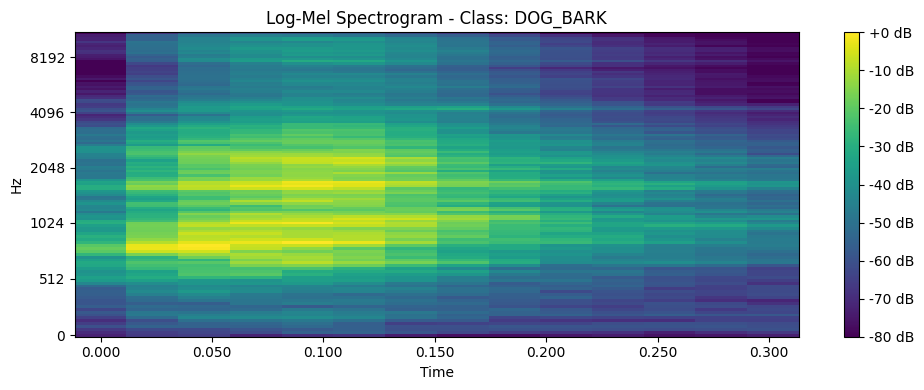

In [ ]:
import os
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the metadata CSV to find file paths and labels
csv_path = "./urbansound8k/UrbanSound8K.csv"
df = pd.read_csv(csv_path)

# Let's peek at the first few rows to verify it loaded
print("Metadata Sample:")
print(df[['slice_file_name', 'fold', 'class']].head())

# 2. Pick a specific row to visualize (e.g., index 0)
sample_row = df.iloc[0]
filename = sample_row['slice_file_name']
fold = sample_row['fold']
sound_class = sample_row['class']

# 3. Construct the exact path to the file inside the cloud instance
# Example target path: ./urbansound8k/fold1/100263-2-0-117.wav
audio_path = os.path.join("./urbansound8k", f"fold{fold}", filename)
print(f"\nLoading sample file: {audio_path} (Class: {sound_class})")

# 4. Load the audio signal
y, sr = librosa.load(audio_path, sr=22050)

# 5. Generate the Log-Mel Spectrogram
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

# 6. Plot the feature matrix
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Log-Mel Spectrogram - Class: {sound_class.upper()}')
plt.tight_layout()
plt.show()

# Preprocessing & Standardization Pipeline

---



* Because the clips have different lengths, this script uses `librosa.util.fix_length` to either pad short clips with silence or trim long clips so they all result in an exact matrix shape of (128, 173).

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

# 1. Load metadata
csv_path = "./urbansound8k/UrbanSound8K.csv"
df = pd.read_csv(csv_path)

# Define core audio parameters
TARGET_SR = 22050          # Standardized sample rate
DURATION = 4                # Target duration in seconds
TOTAL_SAMPLES = TARGET_SR * DURATION  # 88,200 samples per clip
N_MELS = 128                # Height of our spectrogram image

def extract_features(file_path):
    """Loads an audio file, standardizes its length, and computes its Log-Mel Spectrogram"""
    try:
        # Load audio and resample
        y, sr = librosa.load(file_path, sr=TARGET_SR)

        # Standardize length: Pad with zeros if short, truncate if long
        y_fixed = librosa.util.fix_length(y, size=TOTAL_SAMPLES)

        # Generate Mel-Spectrogram
        mel_spect = librosa.feature.melspectrogram(y=y_fixed, sr=TARGET_SR, n_mels=N_MELS)

        # Convert to log scale (decibels)
        mel_db = librosa.power_to_db(mel_spect, ref=np.max)

        return mel_db
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

# 2. Lists to hold our processed data and labels
X_data = []
y_labels = []
fold_ids = []

print("Starting audio preprocessing pipeline...")
# Using a subset of 1000 rows to prototype quickly; change to df.iterrows() for full training
for idx, row in tqdm(df.head(1000).iterrows(), total=1000):
    file_name = row['slice_file_name']
    fold = row['fold']
    class_id = row['classID']

    # Construct file path
    file_path = os.path.join("./urbansound8k", f"fold{fold}", file_name)

    # Extract feature matrix
    features = extract_features(file_path)

    if features is not None:
        X_data.append(features)
        y_labels.append(class_id)
        fold_ids.append(fold)

# 3. Convert lists to NumPy arrays
X_data = np.array(X_data)
y_labels = np.array(y_labels)
fold_ids = np.array(fold_ids)

print("\n--- Pipeline Complete ---")
print(f"Features shape (Samples, Height, Width): {X_data.shape}")
print(f"Labels shape: {y_labels.shape}")

Starting audio preprocessing pipeline...


100%|██████████| 1000/1000 [00:53<00:00, 18.81it/s]


--- Pipeline Complete ---
Features shape (Samples, Height, Width): (1000, 128, 173)
Labels shape: (1000,)


* We have exactly 1,000 processed samples, an image height of 128 (your frequency bins), and a fixed width of 173 (the time frames). The labels align perfectly at (1000,). This means the preprocessing logic is solid and the data is completely standardized.

# Coverting data to Pytorch Sensors

---



* Before building the network, we need to add that missing channel dimension (1 for grayscale) and convert  NumPy arrays into PyTorch Tensors.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Add the channel dimension so shape becomes (1000, 1, 128, 173)
X_reshaped = np.expand_dims(X_data, axis=1)

# 2. Split into Train and Validation sets (80% train, 20% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_reshaped, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 3. Convert to PyTorch float and long tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

# 4. Create DataLoaders for batching
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 25 | Val batches: 7


* The model takes  (1, 128, 173) spectrogram, passes it through convolutional layers to extract audio features, downsamples it with Max Pooling, and passes it to a fully connected layer to output predictions for the 10 classes.

In [4]:
class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()

        # Block 1: Extracts low-level edges/features
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Block 2: Extracts mid-level shapes/patterns
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Block 3: Extracts complex audio signatures
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.4)

        # Fully Connected Layers (Classifier Head)
        # After three MaxPool2d operations on a (128, 173) image, the feature map shrinks to (16, 21)
        self.fc1 = nn.Linear(64 * 16 * 21, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes

    def forward(self, x):
        # Pass through Conv -> BatchNorm -> ReLU -> MaxPooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten the matrix into a vector for the dense layers
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Output raw logits

        return x

# Instantiate the model and move it to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN().to(device)
print(model)

AudioCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=21504, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


To train the network, we need three things: a Loss Function (to measure how wrong the model's guesses are), an Optimizer (to adjust the weights and minimize that loss), and a Loop to iterate through our batches.

Since this is a multi-class classification problem, we will use Cross Entropy Loss and the Adam Optimizer.

In [5]:
import torch.optim as optim

# 1. Hyperparameters & Setup
EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training started on device: {device}\n")

# 2. Outer Loop: Iterate through Epochs
for epoch in range(EPOCHS):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Inner Loop: Iterate through training batches
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero out the parameter gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Update weights
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = (correct_train / total_train) * 100

    # 3. Validation Phase
    model.eval()  # Set model to evaluation mode (disables dropout/batchnorm)
    correct_val = 0
    total_val = 0
    val_loss = 0.0

    with torch.no_grad(): # Disable gradient tracking to save memory and speed up
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"| Train Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTraining Complete!")

Training started on device: cpu

Epoch [1/15] | Train Loss: 2.5304 | Train Acc: 41.12% | Val Loss: 1.2517 | Val Acc: 62.00%
Epoch [2/15] | Train Loss: 1.2639 | Train Acc: 58.50% | Val Loss: 0.9550 | Val Acc: 67.50%
Epoch [3/15] | Train Loss: 1.0127 | Train Acc: 67.38% | Val Loss: 0.8458 | Val Acc: 68.50%
Epoch [4/15] | Train Loss: 0.8094 | Train Acc: 72.00% | Val Loss: 0.5936 | Val Acc: 79.50%
Epoch [5/15] | Train Loss: 0.6278 | Train Acc: 77.12% | Val Loss: 0.4823 | Val Acc: 82.00%
Epoch [6/15] | Train Loss: 0.6340 | Train Acc: 77.38% | Val Loss: 0.5785 | Val Acc: 81.50%
Epoch [7/15] | Train Loss: 0.5430 | Train Acc: 81.38% | Val Loss: 0.4446 | Val Acc: 84.50%
Epoch [8/15] | Train Loss: 0.4531 | Train Acc: 85.62% | Val Loss: 0.4155 | Val Acc: 85.00%
Epoch [9/15] | Train Loss: 0.4423 | Train Acc: 85.12% | Val Loss: 0.4230 | Val Acc: 85.00%
Epoch [10/15] | Train Loss: 0.4349 | Train Acc: 83.00% | Val Loss: 0.3786 | Val Acc: 86.00%
Epoch [11/15] | Train Loss: 0.3315 | Train Acc: 88.50% |

Run this script in a new notebook cell. It will switch your model out of training mode, run a clean inference pass on your hidden validation data, print out a full classification report (Precision, Recall, F1-Score), and display a beautiful heatmap chart.

In [8]:
# Save the trained model parameters to a file
torch.save(model.state_dict(), 'audio_cnn_baseline.pth')
print("Model weights successfully saved to audio_cnn_baseline.pth")

Model weights successfully saved to audio_cnn_baseline.pth


--- Classification Report ---
                  precision    recall  f1-score   support

 air_conditioner       1.00      0.88      0.94        17
        car_horn       0.00      0.00      0.00         2
children_playing       0.58      0.58      0.58        12
        dog_bark       0.79      0.96      0.87        27
        drilling       0.85      0.65      0.73        17
   engine_idling       1.00      0.96      0.98        49
        gun_shot       0.00      0.00      0.00         1
      jackhammer       1.00      1.00      1.00        28
           siren       0.81      1.00      0.90        26
    street_music       0.85      0.81      0.83        21

        accuracy                           0.89       200
       macro avg       0.69      0.68      0.68       200
    weighted avg       0.88      0.89      0.88       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


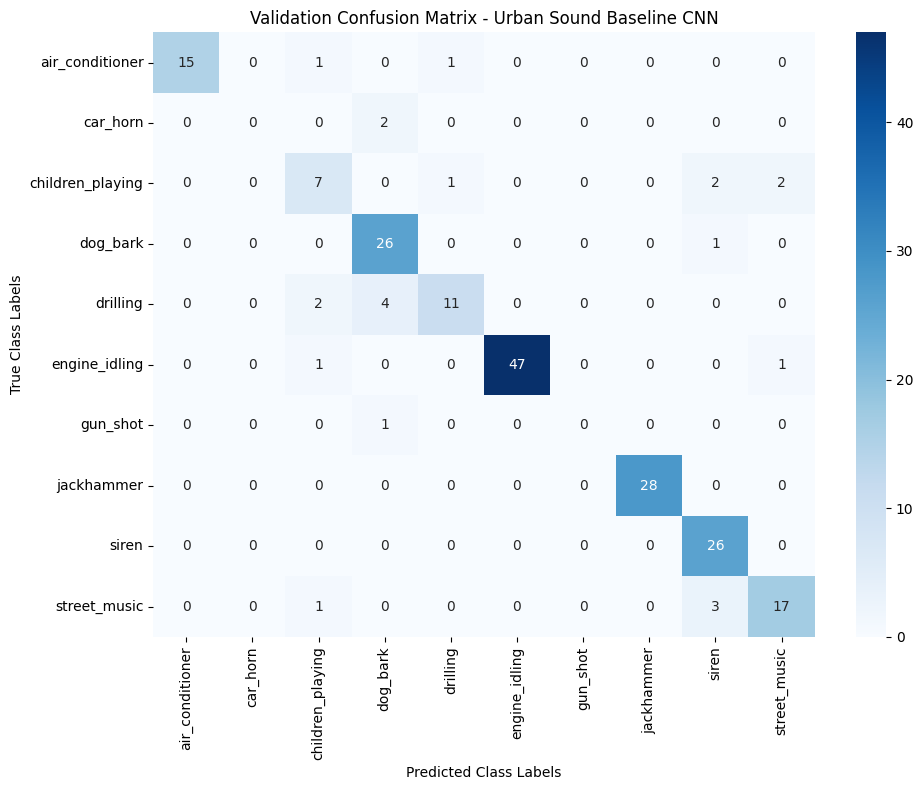

In [7]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Switch model to evaluation mode (disables dropout and batchnorm updates)
model.eval()

all_preds = []
all_labels = []

# 2. Collect all predictions from the validation set loader
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Textual class names matching the UrbanSound8K dataset taxonomy
class_names = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
               'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

# 4. Print textual performance metrics per sound class
print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 5. Compute and plot the Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Validation Confusion Matrix - Urban Sound Baseline CNN')
plt.ylabel('True Class Labels')
plt.xlabel('Predicted Class Labels')
plt.tight_layout()

# Save the plot directly to your cloud workspace so you can download it for GitHub
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()